# Tutorial 4 - Recurrent Neural Networks

In this tutorial we will learn how to **train a recurrent neural network (RNN) to solve a decision task and then study both its behavior and neural activations**. The task example will be a simple **perceptual discrimination task**. Here is the index of the tutorial:

- Installs, packages, auxiliary functions.
- Preparing for the training:
    - Training parameters.
    - Define the task (sample dataset).
    - Define the network.
    - Define the algorithm to train the network.
    - Save config.
- Supervised training of the RNN.
- Run the trained network (and save the behavioral data).
- Network analysis:
    - Behavioral analysis (psychometric curves and psychophysical kernel)
    - General neural analysis.
    - Stimulus and choice decoding from network activity.
    - Trajectories of population activity in latent space

**Copy your responses in this [form](https://forms.gle/wEDVzHcwx9qfSkcH6)**

## 0. Installs, packages, auxiliary functions

### 0.1. Neurogym

We will use the toolbox [**Neurogym**](https://github.com/neurogym/neurogym/) to define the tasks that our RNNs will have to learn.

**NeuroGym** is a curated collection of neuroscience tasks with a common interface. It's main goal is to facilitate training of neural network models on neuroscience tasks.

For detailed instructions on how to install `neurogym` within a conda environment or in editable mode, refer to the [installation instructions](https://github.com/neurogym/neurogym?tab=readme-ov-file#installation).

Here's an overview of the types of task that you can create, and possible wrappers.

<p align="center">
<img src="https://github.com/neurogym/neurogym/raw/main/docs/pipeline.png" alt="drawing" width="1000"/>
</p>

To begin, install the `neurogym` package. This will automatically install all required dependencies, including Stable-Baselines3.

In [ ]:
# Uncomment following lines to install
! pip install gym   # Install gym
! git clone https://github.com/gyyang/neurogym.git  # Install neurogym
%cd neurogym/
! pip install -e .

fatal: destination path 'neurogym' already exists and is not an empty directory.
/content/neurogym
Obtaining file:///content/neurogym
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for neurogym (pyproject.toml) ... done
  Created wheel for neurogym: filename=neurogym-2.2.0-0.editable-py3-none-any.whl size=13068 sha256=dbd7d4febb3ce95b135e6c3b30ed51417ee36c95e30874433b6d15c4752485a5
  Stored in directory: /tmp/pip-ephem-wheel-cache-t0zrzy2p/wheels/50/3c/9c/bd5615ef8a53cd1fb62b8da72e3b9ad7b76a6cbd8c17fd7efd
Successfully built neurogym
  Attempting uninstall: neurogym
    Found existing installation: neurogym 2.2.0
    Uninstalling neurogym-2.2.0:
      Successfully uninstalled neurogym-2.2.0


### 0.2. Imports

Import the packages we need for training and analyzing the RNNs. Especially, we will use the toolbox [pytorch](https://pytorch.org/) to define and train the networks. **Warning**: import will sometimes fail... just restart the kernel and try again!

In [ ]:
#@title Run this code, but feel free to ignore it. {display-mode: "form" }

import copy

import os
from pathlib import Path
import matplotlib.pyplot as plt
import torch.nn as nn
from scipy.special import erf

# packages to save data
import os
from pathlib import Path
import json

# packages to handle data
import numpy as np
import pandas as pd
import copy


# packages to visualize data
import matplotlib.pyplot as plt
import matplotlib as mpl

# import torch and neural network modules to build RNNs
import torch
import torch.nn as nn

# import gym and neurogym to create tasks
import gymnasium as gym
import neurogym as ngym
from neurogym.utils import plotting

import sklearn.model_selection as sklms
import sklearn.discriminant_analysis as sklda

### 0.3. Helper functions

Functions that will make our life easier. Inspect them if you want to understand better how each step is working under the hood.


In [ ]:
#@title Run this code, but feel free to ignore it. {display-mode: "form" }
"""Utilities for data."""

class Dataset(object):
    """Make an environment into an iterable dataset for supervised learning.

    Create an iterator that at each call returns
        inputs: numpy array (sequence_length, batch_size, input_units)
        target: numpy array (sequence_length, batch_size, output_units)

    Args:
        env: str for env id or gym.Env objects
        env_kwargs: dict, additional kwargs for environment, if env is str
        batch_size: int, batch size
        seq_len: int, sequence length
        max_batch: int, maximum number of batch for iterator, default infinite
        batch_first: bool, if True, return (batch, seq_len, n_units), default False
        cache_len: int, default length of caching
    """

    def __init__(self, env, env_kwargs=None, batch_size=1, seq_len=None, max_batch=np.inf,
                 batch_first=False, cache_len=None):
        if env_kwargs is None:
            env_kwargs = {}
        env = ngym.make(env, **env_kwargs)
        env.reset()
        self.env = env
        self.seed()
        self.batch_size = batch_size
        self.batch_first = batch_first

        if seq_len is None:
            # TODO: infer sequence length from task
            seq_len = 1000

        obs_shape = env.observation_space.shape
        action_shape = env.action_space.shape
        if len(action_shape) == 0:
            self._expand_action = True
        else:
            self._expand_action = False
        if cache_len is None:
            # Infer cache len
            cache_len = 1e5  # Probably too low
            cache_len /= (np.prod(obs_shape) + np.prod(action_shape))
            cache_len /= batch_size
        cache_len = int((1 + (cache_len // seq_len)) * seq_len)

        self.seq_len = seq_len
        self._cache_len = cache_len

        if batch_first:
            shape1, shape2 = [batch_size, seq_len], [batch_size, cache_len]
        else:
            shape1, shape2 = [seq_len, batch_size], [cache_len, batch_size]

        self.inputs_shape = shape1 + list(obs_shape)
        self.target_shape = shape1 + list(action_shape)
        self._cache_inputs_shape = shape2 + list(obs_shape)
        self._cache_target_shape = shape2 + list(action_shape)

        self._inputs = np.zeros(self._cache_inputs_shape, dtype=env.observation_space.dtype)
        self._target = np.zeros(self._cache_target_shape, dtype=env.action_space.dtype)

        self._cache()

        self._i_batch = 0
        self.max_batch = max_batch

    def _cache(self, **kwargs):
        for i in range(self.batch_size):
            env = self.env
            seq_start = 0
            seq_end = 0
            while seq_end < self._cache_len:
                # TODO: Right now this only works for env with new_trial
                env.new_trial(**kwargs)
                ob, gt = env.ob, env.gt
                seq_len = ob.shape[0]
                seq_end = seq_start + seq_len
                if seq_end > self._cache_len:
                    seq_end = self._cache_len
                    seq_len = seq_end - seq_start
                if self.batch_first:
                    self._inputs[i, seq_start:seq_end, ...] = ob[:seq_len]
                    self._target[i, seq_start:seq_end, ...] = gt[:seq_len]
                else:
                    self._inputs[seq_start:seq_end, i, ...] = ob[:seq_len]
                    self._target[seq_start:seq_end, i, ...] = gt[:seq_len]
                seq_start = seq_end

        self._seq_start = 0
        self._seq_end = self._seq_start + self.seq_len

    def __iter__(self):
        return self

    def __call__(self, *args, **kwargs):
        return self.__next__(**kwargs)

    def __next__(self, **kwargs):
        self._i_batch += 1
        if self._i_batch > self.max_batch:
            self._i_batch = 0
            raise StopIteration

        self._seq_end = self._seq_start + self.seq_len

        if self._seq_end >= self._cache_len:
            self._cache(**kwargs)

        if self.batch_first:
            inputs = self._inputs[:, self._seq_start:self._seq_end, ...]
            target = self._target[:, self._seq_start:self._seq_end, ...]
        else:
            inputs = self._inputs[self._seq_start:self._seq_end]
            target = self._target[self._seq_start:self._seq_end]

        self._seq_start = self._seq_end
        return inputs, target
        # return inputs, np.expand_dims(target, axis=2)

    def seed(self, seed=None):
        self.env.seed(seed)



def get_dataset(envid, env_kwargs, training_kwargs):
    """
    Create neurogym dataset and environment.

    args:
        envid (str): name of the task on the neurogym library
        env_kwargs (dict): task parameters
        training_kwargs (dict): training parameters

    returns:
        dataset (neurogym.Dataset): dataset object from which we can sample trials and labels
        env (gym.Env): task environment
    """

    # Make supervised dataset using neurogym's Dataset class
    dataset = Dataset(envid, env_kwargs=env_kwargs,
                      batch_size=training_kwargs['batch_size'],
                      seq_len=training_kwargs['seq_len'])
    env = dataset.env

    return dataset, env

if __name__ == '__main__':
    dataset = ngym.Dataset(
        'PerceptualDecisionMaking-v0', env_kwargs={'dt': 100}, batch_size=32,
        seq_len=40)
    inputs_list = list()
    for i in range(2):
        inputs, target = dataset()
        inputs_list.append(inputs)
    # print(inputs.shape)
    # print(target.shape)

def get_modelpath(envid):
    """
    to create a path to save the data from the network that we will analize.
    """
    # Make a local file directories
    path = Path('.') / 'files'
    os.makedirs(path, exist_ok=True)
    path = path / envid
    os.makedirs(path, exist_ok=True)

    return path

def plot_trials_timestep(inputs, actions, gt, perf, env_kwargs, num_steps=None, reward=None):
    inputs = np.array(inputs)
    actions = np.array(actions)
    gt = np.array(gt)
    perf = np.array(perf)
    # Plot first 40 steps
    if num_steps is None:
        num_steps = len(gt)
    f, ax = plt.subplots(ncols=1, nrows=3, figsize=(8, 4), dpi=150, sharex=True)

    ax[0].plot(np.arange(1, num_steps+1)*env_kwargs['dt'], inputs[:num_steps, 0], label='Fixation')
    ax[0].plot(np.arange(1, num_steps+1)*env_kwargs['dt'], inputs[:num_steps, 1], label='Stim. L.')
    ax[0].plot(np.arange(1, num_steps+1)*env_kwargs['dt'], inputs[:num_steps, 2], label='Stim. R.')
    ax[0].set_ylabel('Inputs')
    ax[0].legend()
    ax[1].plot(np.arange(1, num_steps+1)*env_kwargs['dt'], gt[:num_steps], label='Targets', color='k')
    ax[1].plot(np.arange(1, num_steps+1)*env_kwargs['dt'], actions[:num_steps], label='Choice', linestyle='--')
    ax[1].set_ylabel('Actions / Targets')
    ax[1].legend()
    ax[2].plot(np.arange(1, num_steps+1)*env_kwargs['dt'], perf[:num_steps], label='Accuracy')
    if reward is not None:
        reward = np.array(reward)
        ax[2].plot(np.arange(1, num_steps+1)*env_kwargs['dt'], reward[:num_steps], label='reward')
    ax[2].set_ylabel('Performance')
    ax[1].legend()
    ax[2].set_xlabel('Time (ms)')


def probit(x, beta, alpha):
    """
    Return probit function with parameters alpha and beta.

    Parameters
    ----------
    x : float
        independent variable.
    beta : float
        sensitiviy.
    alpha : TYPE
        bias term.

    Returns
    -------
    probit : float
        probit value for the given x, beta and alpha.

    """
    probit = 1/2*(1+erf((beta*x+alpha)/np.sqrt(2)))
    return probit

class efficieNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(efficieNet, self).__init__()

        # build a recurrent neural network with a single recurrent layer and rectified linear units
        self.vanilla = nn.RNN(input_size, hidden_size, nonlinearity='relu')
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # get the output of the network for a given input
        out, _ = self.vanilla(x)
        x = self.linear(out)
        return x, out

def plot_activity(activity, obs, config, trial):

    # Load and preprocess results
    f, ax = plt.subplots(figsize=(5, 4), nrows=2, dpi=150)

    # time in ms
    t_plot = np.arange(activity.shape[1]) * config['dt']

    # plot the observations for one trial. Note that we will visualize the inputs as a matrix instead of traces, as we have done before.
    im = ax[0].imshow(obs[trial].T, aspect='auto', vmin=0, vmax=1)
    ax[0].set_title('Observations')
    ax[0].set_ylabel('Stimuli')

    # change the xticks to show time in ms
    ax[0].set_xticks(np.arange(0, activity.shape[1], 10))
    ax[0].set_xticklabels(t_plot[::10])
    plt.colorbar(im, ax=ax[0])
    # plot the activity for one trial
    im = ax[1].imshow(activity[trial].T, aspect='auto', cmap='viridis')
    ax[1].set_title('Activity')
    ax[1].set_xlabel('Time (ms)')
    ax[1].set_ylabel('Neurons')
    plt.colorbar(im, ax=ax[1])
    # change the xticks to show time in ms
    ax[1].set_xticks(np.arange(0, activity.shape[1], 10))
    ax[1].set_xticklabels(t_plot[::10])

    plt.tight_layout()

def decoding_from_hidden_units(activity, decoded_variable, n_splits = 100):

  # set
  mean_acc = np.zeros([n_splits, activity.shape[1]]) * np.nan

  for i in range(n_splits):

      # transpose tensor to be shape [trials, time, neurons]
      for xi,x in enumerate(activity.transpose(1,0,2)):

          # split data into train and test sets using sklms.
          x_train, x_test, y_train, y_test = sklms.train_test_split(x, decoded_variable, random_state=i)

          # fit a linear discriminant analysis model to the training data using sklda
          lda_fitted = sklda.LinearDiscriminantAnalysis(solver='lsqr').fit(X=x_train, y=y_train)

          # predict the labels for the test data
          y_pred = lda_fitted.predict(x_test)

          # compute the accuracy of the model
          correct = 1 - np.abs(y_pred - y_test)

          mean_acc[i,xi] = correct.mean()

  return mean_acc

def plot_decoding_results(mean_acc, obs, dt, variable='stimulus', lbl=[]):

  # calculate 95% CI
  ci_acc = np.percentile(mean_acc, [5,95], axis=0)

  # for plotting: time axis, stim and resp times
  t_plot = np.arange(activity.shape[1]) * dt
  stim_onset = t_plot[np.where(obs[0,:,1]!=0)[0][0]]
  resp_onset= t_plot[np.where(obs[0,:,1]==0)[0][-1]]

  plt.figure(figsize=(4,3), dpi=150)
  plt.plot(stim_onset, .48, '^', color = 'r', ms=10)
  plt.plot(resp_onset, .48, '^', color='b', ms=10)
  plt.plot(t_plot, np.zeros(mean_acc.shape[1])+.5, 'k--', alpha=.2)

  # plot linear classification accuracy
  if mean_acc.ndim==3: # multiple lines
    # colors corresponding to different values of color gradient
    colors = plt.get_cmap('magma')(np.linspace(0.1,.9, mean_acc.shape[2]))

    # plot mean acc for each coherence level
    for ci in range(mean_acc.shape[2]):
      plt.plot(t_plot, np.mean(mean_acc[:,:,ci], axis=0), color=colors[ci], label=lbl[ci])
      plt.fill_between(t_plot, ci_acc[0,:,ci], ci_acc[1,:,ci], color=colors[ci], alpha=.2)

  else:
    plt.plot(t_plot, np.mean(mean_acc, axis=0), 'k')
    plt.fill_between(t_plot, ci_acc[0], ci_acc[1], color='k', alpha=.2)

  plt.ylabel('classification accuracy')
  plt.xlabel('time')
  plt.xlim(t_plot[0],t_plot[-1])
  plt.title('decoding '+variable)

  if mean_acc.ndim==3:
    plt.legend(frameon=False)

def analysis_activity_by_condition(activity, df, config, conditions=['choice']):
    """
    Plot single neuron activity by condition.
    """
    for condition in conditions:
        values = pd.unique(df[condition])
        f, ax = plt.subplots(figsize=(10, 3), ncols=len(values), sharex=True, dpi=150)
        t_plot = np.arange(activity.shape[1]) * config['dt']
        for i_v, value in enumerate(values):
            # plot the average activity across neurons and trials for each condition
            a = activity[df[condition] == value]
            ax[i_v].imshow(a.mean(axis=0).T, aspect='auto', cmap='viridis')
            ax[i_v].set_xlabel('Time (ms)')
            ax[i_v].set_ylabel('Mean activity for ' + condition + ' = ' + str(value))
            # change the xticks to show time in ms
            ax[1].set_xticks(np.arange(0, activity.shape[1], 10))
            ax[1].set_xticklabels(t_plot[::10])

        # plt.legend(title=condition, loc='center left', bbox_to_anchor=(1.0, 0.5))


def plot_latent_trajectories(X_pca_3d, cog_variable, lbl='choice', n_plot_seq=50):
  fig, ax = plt.subplots(figsize=(10, 7))
  cmap = plt.get_cmap('coolwarm')
  norm = plt.Normalize(cog_variable.min(), cog_variable.max())

  for i in range(n_plot_seq):
      # Extract trajectory for sequence i, first 9 steps
      traj = X_pca_3d[i, :, :]
      color = cmap(norm(cog_variable[i]))

      # Plot the line trajectory
      ax.plot(traj[:, 0], traj[:, 1], color=color, alpha=0.6, linewidth=1.5)

      # Start point: Triangle (t = 0)
      ax.scatter(traj[0, 0], traj[0, 1], color=color, marker='^', s=80, edgecolors='black', zorder=5)

      # Final point: Star (t = 8)
      ax.scatter(traj[-1, 0], traj[-1, 1], color=color, marker='*', s=120, edgecolors='black', zorder=5)

  # Formatting the plot
  ax.set_xlabel('Principal Component 1')
  ax.set_ylabel('Principal Component 2')
  ax.set_title(f'PCA Trajectories')
  ax.grid(True, linestyle='--', alpha=0.5)

  # Add a colorbar for signed_coh
  sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
  sm.set_array([])
  fig.colorbar(sm, ax=ax, label=lbl)

  plt.tight_layout()

We're ready to start! The 3 important steps to train the network are the following:
- define the **task**
- define the **network**
- define the **training algorithm**

## 1. Defining the task
We first need to select the task among all the types of task in `neurogym`. Here we will use `PerceptualDecisionMaking`, which allows for n-alternative-forced choice tasks based on the properties of the stimulus.

| Class Name | Description |
| :--- | :--- |
| `ContextDecisionMaking` | Two-alternative forced choice task where context signals which feature to attend to. |
| `DelayComparison` | Discriminate which of two stimuli (separated by a delay) has a higher magnitude. |
| `DelayMatchToSample` | Agent must report whether a test stimulus matches the sample shown previously. |
| `DelayMatchCategory` | Matches a stimulus to a category (e.g., grouped by color/shape) rather than identity. |
| `DelayNonMatchToSample` | Agent must respond only when the test stimulus does not match the sample. |
| `EconomicDecisionMaking` | Choosing between rewards of different values and associated "costs." |
| `GoNogo` | Simple inhibitory control task requiring response for one stimulus and none for the other. |
| `IntervalDiscrimination` | Discriminating between different temporal intervals or pulse timings. |
| `MotorTiming` | Task requiring the production of an action after a specific learned time duration. |
| `MultiSensoryIntegration` | Integration of information from multiple sensory modalities to reach a decision. |
| `NBack` | Working memory task requiring matching the current stimulus to one shown $N$ steps ago. |
| `Null` | A baseline task with no input or required output (resting state). |
| `PerceptualDecisionMaking` | Integration of noisy evidence (e.g., motion) over time to make a binary choice. |
| `PostDecisionBiasing` | Task where an initial decision influences the reporting of a second stimulus. |
| `ProbabilisticReasoning` | Reasoning based on the integration of multiple cues with different reward probabilities. |
| `PulseDiscrimination` | Comparing the total number or intensity of pulses in two separate streams. |
| `ReadySetGo` | Measuring a "Ready-Set" interval and reproducing it as a "Set-Go" interval. |
| `ReversalLearning` | Adapting to changes in reward contingencies where the "correct" stimulus flips. |
| `SequenceLearning` | Recognizing or predicting the next stimulus in a learned temporal sequence. |
| `SpatialWorkingMemory` | Remembering and responding to a specific spatial location after a delay. |

Let's now create and explore the environment using the `PerceptualDecisionMaking` class from neurogym. We need to define the parameters of the task with the following variables:
- `dim_ring = 2`: Two possible choices (left/right) represented at 0° and 180°. Note that the ring architecture can support any number of choices, making it suitable for more complex decision-making scenarios.
- `coherence`: strengths of the stimulus signal (named here as a reminder of motion coherence in random dot kinematograms). We will use the default values here that span very weak and strong stimulus strengths.
- `sigma = 1.0`: Standard deviation of the noise added to the inputs. This noise is applied independently at each time step in the stimulus period.
- `timing`: a dictionary defining the duration (in milliseconds) of the different epochs in each trial: fixation, stimulus period, delay and decision period. These durations can be either fixed or drawn from a distribution

Some wrappers could be used to modify the environment behavior, but we will not explore them here, e.g.:
- `ReactionTime` wrapper allows the agent to respond at any time after stimulus onset.
- `SideBias` wrapper introduces blocks where one side is more likely than the other.

In [ ]:
dt = 100 # value of time step (in ms)
dim_ring = 2  # Number of choices in the ring representation
sigma = 1.0 # Standard deviation of the Gaussian noise in the ring representation
timing = {
    "fixation": 300, # instead of a fixed time, we could use variable duration using e.g. `TruncExp(600, 400, 700)`,
    "stimulus": 500, # duration of stimulus presentation
    "delay": 0, # duration of delay (here no delay, it is not a working memory task)
    "decision": 100, # just one time step where the response should be performed
}

# Set up task parameters
task = 'PerceptualDecisionMaking-v0' # name of the task on the neurogym library
# To display all registered environment names instead uncomment and run these two lines
#from neurogym import info
#info.show_all_tasks()

env_kwargs = {'dt': dt,
                'timing': timing,
                'sigma': sigma,
                'dim_ring': dim_ring}

In [ ]:
# Create and wrap the environment
env = ngym.make(task, **env_kwargs)

#uncomment to make it a reaction-time task where the agent can respond at any time after fixation offset rather than right after
#env = ReactionTime(env, end_on_stimulus=True)

# Print environment specifications
print("Trial timing (in milliseconds):")
print(env.timing)

print("\nObservation space structure:")
print(env.observation_space)

print("\nAction space structure:")
print(env.action_space)
print("Action mapping:")
print(env.action_space.name)

Trial timing (in milliseconds):
{'fixation': 300, 'stimulus': 500, 'delay': 0, 'decision': 100}

Observation space structure:
Box(-inf, inf, (3,), float32)

Action space structure:
Discrete(3)
Action mapping:
{'fixation': 0, 'choice': [1, 2]}


/usr/local/lib/python3.12/dist-packages/gymnasium/core.py:311: UserWarning: WARN: env.timing to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.timing` for environment variables or `env.get_wrapper_attr('timing')` that will search the reminding wrappers.
  logger.warn(


### 1.2 Generating a dataset of stimuli and targets

We need to define the **size of the dataset** to simulate:
- `seq_len`: number of time steps in each sequence. You can think of it as a block of trials.
- `batch_size`: number of sequences per batch. During training, the network will be trained on batches of sequences that contain the inputs to the network and the target outputs (or labels).



In [ ]:
# we want 10 trials per sequence, and there are 9 time steps per trial, so 90 time steps per sequence
num_trials_per_seq = 10
num_steps_per_trial = int((timing['fixation']+timing['stimulus']+timing['delay']+timing['decision'])/dt)
seq_len = num_steps_per_trial * num_trials_per_seq

# Set up config:
training_kwargs = {'dt': dt,
                  # 'lr': 1e-2,
                  # 'n_epochs': 8000,
                   'batch_size': 16,
                   'seq_len': seq_len}

After having defined how the task (*the environment*) is implemented and which are the training hyperparameters, we now define a **function that builds the environment**. This function `get_dataset` also provides a dataset object, from which we will sample the trials and labels (targets) that will be used to train the network.

In [ ]:
# call function to sample
dataset, env = get_dataset(envid=task, env_kwargs=env_kwargs, training_kwargs=training_kwargs)

The `dataset` object provides the inputs and targets to train the RNN:
- The **inputs** are the stimuli that the network will receive at each time step. Here there are three: a *fixation* input indicating that the agent should "fixate" i.e. not perform a response before stimulus presentation; *stimulus left* and *stimulus right*, which are the amplitude of the two stimuli that the network must compare.
- The **targets** are the labels that the network will have to predict at each time step. In our case this is just a scalar: it should 1 or 2 at the decision period (depending on the stimulus), and 0 for all other time steps (during fixation or stimulus presentation).

Here we mark the start of each trial with a vertical bar (but no input tells the network that a new trial has started).

inputs shape: (90, 16, 3)
labels shape: (90, 16)


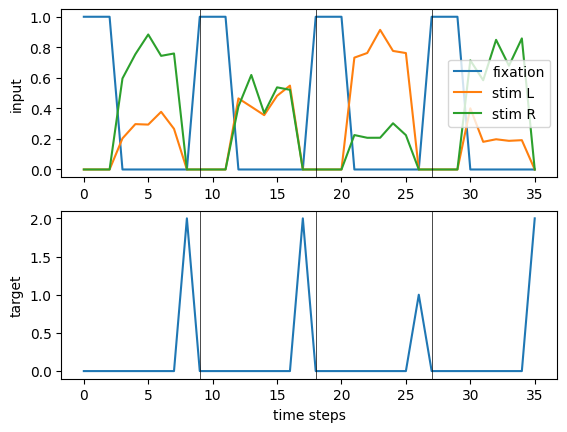

In [ ]:
inputs, labels = dataset()
print('inputs shape:', inputs.shape)
print('labels shape:', labels.shape)

fig, ax = plt.subplots(nrows=2, ncols=1);
ax[0].plot(inputs[:36,0,:], label = ['fixation','stim L','stim R']);
[ax[0].axvline(_x, linewidth=.5, color='k') for _x in 9*np.arange(1,4)]
ax[0].legend();
ax[0].set_ylabel('input');

ax[1].plot(labels[:36,0]);
[ax[1].axvline(_x, linewidth=.5, color='k') for _x in 9*np.arange(1,4)]
ax[1].set_ylabel('target');
ax[1].set_xlabel('time steps');

#print('Example inputs:')
#print('Fixation     Stimulus Left Stimulus Right')
#print(inputs[:20, 0, :])
#print('Example labels:')
#print(labels[:20, 0])

**Question 1 -  Explain the relationship between the values taken by the target and the inputs**

*Copy your response in the Google form*

###  1.3 Performance of a random agent
Before studying the performance of an RNN, let's simulate a random agent to get a feel of how the environment works. The agent will randomly choose between the three options (fixate/left/right), and we will visualize its behavior over 5 trials  using `plot_trials_timestep`. Feel free to run it several times, or explore different agents (random, constant) to get to understand the task.

Note: agents receive positive rewards (of magnitude 1) when they perform the correct action during the response period, but they also get punished (reward -0.1) whenever they perform an action (other than fixation) during any other time step.


TWe will also plot the reward received by the agent at each time step, as well as the performance on each trial. Note that performance is only defined at the end of a trial: it is 1 if the agent made the correct choice, and 0 otherwise.

To keep track of the agent's behavior, we will use the Monitor wrapper, which monitors training by:
- Tracking and saving behavioral data (rewards, actions, observations) every `sv_per` steps.
- Generating visualization figures during training if `sv_fig=True`.
- Providing progress information if `verbose=True`.

Here, we’ll use the wrapper solely to compute the agent’s performance, but later it will help us assess learning and save intermediate results.

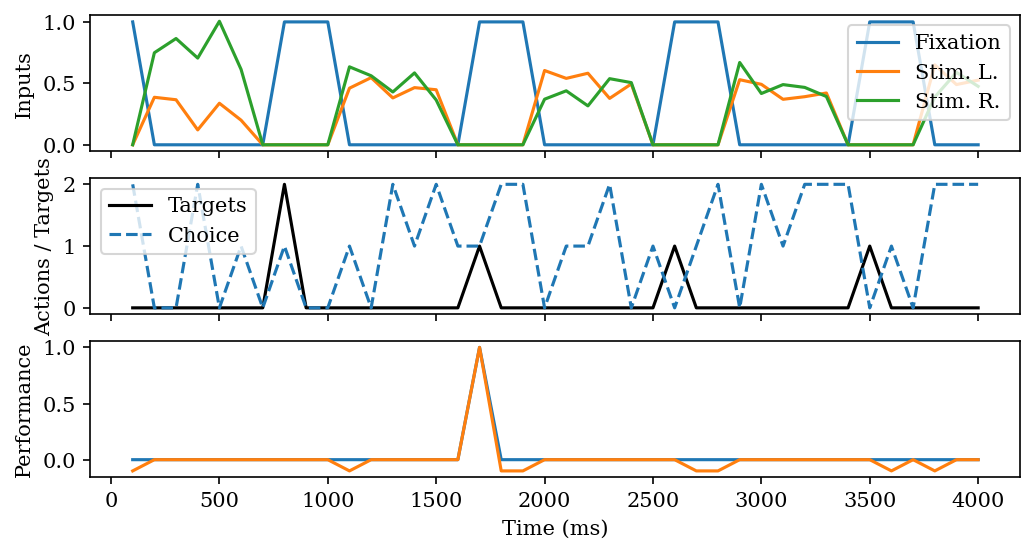

In [ ]:
mpl.rcParams['font.family'] = ['DejaVu Serif']
num_steps = 2000 # total number of steps
inputs = []
actions = []
gt = []
perf = []
reward = []
correct_choice = []
trial_count = 0
for stp in range(int(num_steps)): # for each step in sequence

    # sample a random action from the action space (so here 0, 1 or 2)
    # You can also try to set the action to one constant value, e.g. action = 1
    action = env.action_space.sample()

    # declare this action to the environment and compute the associated reward
    # for this action (and next input)
    inp, rew, _, _, info = env.step(action)

    # append to lists
    inputs.append(inp)
    actions.append(action)
    reward.append(rew)
    gt.append(info['gt'])
    if info['new_trial']:
        perf.append(info['performance'])
        correct_choice.append(info['gt'])
    else:
        perf.append(0)

# let's plot the first 20 trials
plot_trials_timestep(inputs=inputs, actions=actions, gt=gt, perf=perf, reward=reward, env_kwargs=env_kwargs, num_steps=40)

**Question 2: Explain the reward that random agent receives.** (orange trace)

*Copy your response in the Google form*

# 2. Defining the network

It's finally time to define the network that we want to train. As you have seen in the lecture, RNNs are defined by a set of units that are connected to each other.



<p align="center">
<img src="https://drive.google.com/uc?export=view&id=1ENHA_qKp3Cl_D0qagUMAJTLHKdJpA1nb" alt="drawing" width="1000"/>
</p>


An RNN receives an input $x$ that changes from timestep to timestep and produces an associated output $y$. The activity of their units at the previous  timestep ($h_{t-1}$) is passed to the network as an extra input in the current timestep ($h_t$), implementing the **recurrence** of the circuits.

The connections between the different units will be defined by a matrix of weights ($W_R$). The connections from input to each unit and from each unit to the output are defined by connectivity matrices $W_i$ and $W_y$, respectively.

Then, we need to define the transfer function of the units ($g_h$). We will use rectified linear units (ReLu) which just take the positive part of the input.

Finally, we will readout the units activity with a linear projection to the output units ($g_y(x)=x$).

Let's first **define the architecture of the network**:
- the number (*dimensionality*) of inputs.
- the number of hidden units (neurons) in the network.
- the dimensionality of outputs.

The dimensionality of inputs (3) and outputs (1) is imposed by the task, so we really can just select the number of hidden units. We'll take 64, which is enough to perform a simple task like this one.

The **parameters of the model** (which will be shaped by training ) are the connectivity matrices ($W_R$, $W_i$ and $W_y$) as well as the unit biases ($b_h$ and $b_y$).

In [ ]:
# Set up config:
num_neurons = 64

net_kwargs = {'hidden_size': num_neurons,
              'action_size': env.action_space.n, # dimensionality of output
              'input_size': env.observation_space.shape[0]} # size of the input to the network
training_kwargs['env_kwargs'] = env_kwargs
training_kwargs['net_kwargs'] = net_kwargs

In the following, we define a `Net` class, which creates our network from standard modules in `pytorch`. Classes can have associated *methods*, which are functions specified uniquely for object of the respective class. Our Net class will have:
- An `_init_` method that will be run when a new object is created and defines the network architecture. The **connectivity matrices will be initiated at small random values** (and biases at 0).
- A `forward` method, that receives the input and returns the output of the network (based on the equations described above).

**Coding exercice: complete the code below for the forward pass of the algorithm** (check `??` for missing parts)

In [ ]:
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
      # Initialize parameters of the network
        super(Net, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        # Initialize weights and biases for RNN
        self.W_i = nn.Parameter(torch.randn(hidden_size, input_size) * 0.01) # input connectivity matrix
        self.W_R = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01) # recurrent connectivity matrix
        self.b_h = nn.Parameter(torch.zeros(hidden_size)) # unit biases

        # Initialize weights and biases for Linear layer
        self.W_y = nn.Parameter(torch.randn(output_size, hidden_size) * 0.01)
        self.b_y = nn.Parameter(torch.zeros(output_size))

    def forward(self, x):
        seq_len, batch_size, _ = x.size()
        h = torch.zeros(batch_size, self.hidden_size, device=x.device)  # Initial hidden state

        # Apply the RNN step by step
        outputs = []
        for t in range(seq_len):
            x_t = x[t, :, :]

            # !! Complete the code below
            h = nn.functional.relu(torch.matmul(x_t, self.??.T) + torch.matmul(h, self.??.T) + self.??)
            outputs.append(h.unsqueeze(0))

        out = torch.cat(outputs, dim=0)

        # Apply the linear layer
        # !! Complete the code below
        x = torch.matmul(out, self.??.T) + self.??
        return x, out

We will now create an *instance* of the `Net` class with the desired hyperparameters as defined above. We will then pass this network to our GPU for training.

In [ ]:
# check if GPU is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Define network instance from the Net class
net = Net(input_size=env.observation_space.shape[0],
          hidden_size=net_kwargs['hidden_size'],
          output_size=env.action_space.n)

# Faster alternative: import efficieNet as Net and do net = Net(input_size=env.observation_space.shape[0],...
# efficieNet is the same implementation as Net but using PyTorch's built-in RNN module
# Move network to the device (CPU or GPU)
net = net.to(device)

## 3. Supervised training of the RNN

### 3.1. Defining the algorithm to train the network



To teach the network to perform the task, we will use a supervised learning approach. This means that we will provide the network with the inputs and the target outputs (or labels) and we will train the network to predict the target outputs from the inputs. For that we need a loss function that quantifies the difference between the network's predictions and the target outputs.

<p align="center">
<img src="https://drive.google.com/uc?export=view&id=1cJjCcgc3jgdrsd2nq0AsDq628nK0eUZA" alt="drawing" width="600"/>
</p>

We will use the cross-entropy loss function, which is commonly used for classification tasks (here the network has to classify the stimuli into two categories). The cross-entropy loss function is defined as:

$$L = - \sum_{t=1}^{N} T^{(t)} \log p(\hat{T}^{(t)}\mathbin{=}T^{(t)})$$

where $L$ is the loss, $N$ is the number of samples, $T^{(t)}$ is the target output and $\hat{T}^{(t)}$ is the network's prediction for the $t$-th sample (drawn from a distribution based on $y^{(t)}$ values passed through softmax).

We will also define the optimizer that will be used to train the network. We will use Adam, which is a popular optimizer commonly used in deep learning, with learning rate of $\alpha = 0.01$.

Note that RNNs can also be trained with reinforcement learning (see an example [here](https://github.com/neurogym/neurogym/blob/011101c467fb6c072b87f488361249d365623515/docs/examples/perceptualdecisionmaki)), although they're slower to learn.

In [ ]:
# Define loss: instance of the CrossEntropyLoss class
criterion = nn.CrossEntropyLoss()

# Define optimizer
lr= 1e-2 #learning rate
optimizer = torch.optim.Adam(net.parameters(), lr=lr)

### 3.2 Training the network
Now is the time to train the network!
We use a fixed number of training epochs (one epoch means an evaluation of the loss function with a given set of parameters) and monitor how the loss function evolves.

In [ ]:
print('Training task ', task)

num_epochs = 8000

# We'll keep track of the loss as we train.
# It is initialized to zero and then monitored over training interations
running_loss = 0.0

for i in range(num_epochs):

    # get inputs and labels and pass them to the GPU - we always use the same dataset
    inputs, labels = dataset()

    # convert to torch
    inputs = torch.from_numpy(inputs).type(torch.float).to(device)
    labels = torch.from_numpy(labels.flatten()).type(torch.long).to(device)

    # print shapes of inputs and labels (before first epoch)
    if i == 0:
        print('inputs shape: ', inputs.shape)
        print('labels shape: ', labels.shape)
        print('Max labels: ', labels.max())

    # we need zero the parameter gradients to re-initialize and avoid they accumulate across epochs
    optimizer.zero_grad()

    # FORWARD PASS: get the output of the network for a given input
    outputs, _ = net(inputs)

    #reshape outputs so they have the same shape as labels
    outputs = outputs.view(-1, env.action_space.n)

    #  compute loss with respect to the labels
    loss = criterion(outputs, labels)

    # compute gradients (backpropagation through time)
    loss.backward()

    # update weights accordingly
    optimizer.step()

    # print average loss over last 200 training iterations and save the current network
    running_loss += loss.item()
    if i % 200 == 199:
        print('{:d} loss: {:0.5f}'.format(i + 1, running_loss / 200))
        running_loss = 0.0

        # save current state of network's parameters
        torch.save(net.state_dict(), get_modelpath(task) / 'net.pth')

print('Finished Training!')

Training task  PerceptualDecisionMaking-v0
inputs shape:  torch.Size([90, 16, 3])
labels shape:  torch.Size([1440])
Max labels:  tensor(2)


/usr/local/lib/python3.12/dist-packages/gymnasium/core.py:311: UserWarning: WARN: env.new_trial to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.new_trial` for environment variables or `env.get_wrapper_attr('new_trial')` that will search the reminding wrappers.
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/core.py:311: UserWarning: WARN: env.ob to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.ob` for environment variables or `env.get_wrapper_attr('ob')` that will search the reminding wrappers.
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/core.py:311: UserWarning: WARN: env.gt to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.gt` for environment variables or `env.get_wrapper_attr('gt')` that will search the reminding wr

200 loss: 0.62785
400 loss: 0.40033
600 loss: 0.29044
800 loss: 0.16541
1000 loss: 0.11330
1200 loss: 0.09605
1400 loss: 0.08884
1600 loss: 0.08514
1800 loss: 0.08295
2000 loss: 0.08155
2200 loss: 0.08059
2400 loss: 0.07990
2600 loss: 0.07939
2800 loss: 0.07900
3000 loss: 0.07868
3200 loss: 0.07843
3400 loss: 0.07824
3600 loss: 0.07807
3800 loss: 0.07794
4000 loss: 0.07782
4200 loss: 0.07772
4400 loss: 0.07765
4600 loss: 0.07758
4800 loss: 0.07751
5000 loss: 0.07747
5200 loss: 0.07742
5400 loss: 0.07737
5600 loss: 0.07734
5800 loss: 0.07728
6000 loss: 0.07709
6200 loss: 0.07050
6400 loss: 0.04601
6600 loss: 0.03473
6800 loss: 0.03321
7000 loss: 0.03285
7200 loss: 0.03226
7400 loss: 0.03264
7600 loss: 0.03240
7800 loss: 0.03180
8000 loss: 0.03248
Finished Training!


**Q3- What can you tell whether training went well?**

*Copy your response in the Google form*

## 4. Run the trained network (and save the behavioral data)

We will now run the network that we have trained. Importantly, we will record the activity of the network and the output behaviour for further analyses.

Now, we'll make a new instance of the `Net` class and populate it with hyperparameters from our config file, as well as the trained weights.

/usr/local/lib/python3.12/dist-packages/gymnasium/core.py:311: UserWarning: WARN: env.new_trial to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.new_trial` for environment variables or `env.get_wrapper_attr('new_trial')` that will search the reminding wrappers.
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/core.py:311: UserWarning: WARN: env.ob to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.ob` for environment variables or `env.get_wrapper_attr('ob')` that will search the reminding wrappers.
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/core.py:311: UserWarning: WARN: env.gt to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.gt` for environment variables or `env.get_wrapper_attr('gt')` that will search the reminding wr

Shape of inputs: torch.Size([9, 1, 3])
Average performance 0.862
(1000, 9, 3)
[0 0 0 0 0 0 0 0 2]
Activity stats:
Max: 3.8710616, Min: 0.0, Mean: 0.1763617, Std: 0.41908088, Shape: (1000, 9, 64)


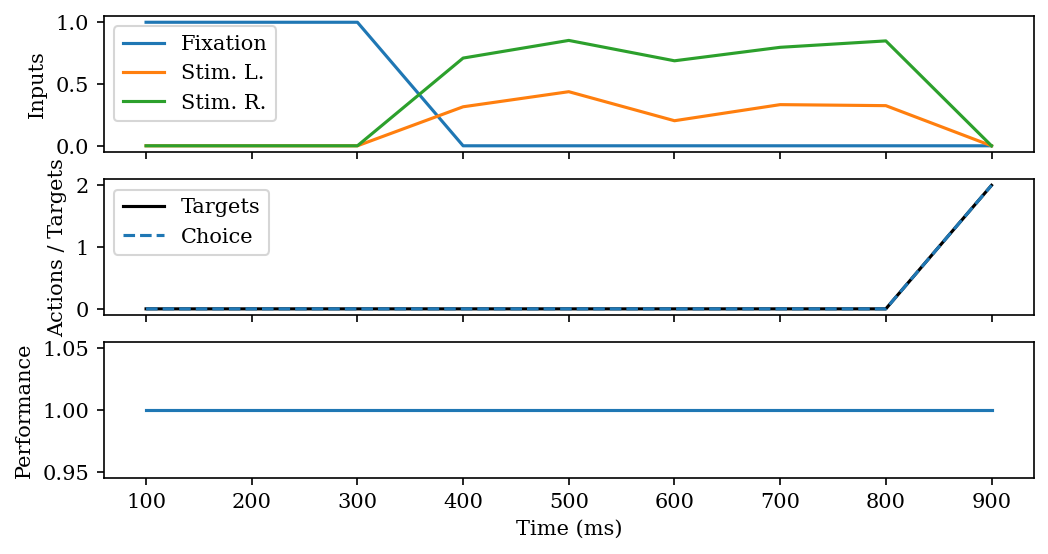

In [ ]:
# how many sequences we want to run (remember each sequence is composed of multiple trials)
num_seq = 1000

# Since we will not train the network anymore, we can turn off the gradient computation (will run faster). The most commun way to do this is to use the context manager torch.no_grad() as follows:
with torch.no_grad():
    net = Net(input_size=training_kwargs['net_kwargs']['input_size'],
              hidden_size=training_kwargs['net_kwargs']['hidden_size'],
              output_size=training_kwargs['net_kwargs']['action_size'])

    net = net.to(device) # pass to GPU for running forwards steps

    # load the trained network's weights from the saved file
    net.load_state_dict(torch.load(get_modelpath(task) / 'net.pth'))


    # empty lists / dataframe to store activity, choices, and trial information
    activity = []
    obs = []
    actions = []
    gt = []
    perf = []
    df = pd.DataFrame()

    for i in range(num_seq):

        # create new trial
        env.new_trial()

        # read out the inputs in that trial
        inputs = torch.from_numpy(env.ob[:, np.newaxis, :]).type(torch.float)
        # as before you can print the shapes of the variables to understand what they are and how to use them
        # do this for the rest of the variables as you build the code
        if i == 0:
            print('Shape of inputs: ' + str(inputs.shape))

        # get the network's prediction for the current input
        action_pred, hidden = net(inputs)
        action_pred = action_pred.numpy()

        # get the network's choice.
        # Take into account the shape of action_pred. Remember that the network makes a prediction for each time step in the trial.
        # Which is the prediction we really care about when evaluating the network's performance?
        choice = np.argmax(action_pred[:, 0, :], axis=1)

        # check if the choice is correct
        # Again, which is the target we want when evaluating the network's performance?
        correct = choice[-1] == env.gt[-1]

        # Log trial info
        trial_info = env.trial
        relative_evidence = np.diff(inputs.numpy()[3:-1,:,1:]).flatten() # instantaneous stimulus evidence
        trial_info.update({'correct': correct, 'choice': choice[-1], 'stimulus': relative_evidence}) # Update trial_info with additional information
        df = pd.concat([df, pd.DataFrame([trial_info])], ignore_index=True)

        # Log activity
        activity.append(np.array(hidden)[:, 0, :])

        # Log the inputs (or observations) received by the network
        obs.append(env.ob)
        actions.append(choice)
        gt.append(env.gt)
        perf.append(choice == env.gt)


    print('Average performance', np.mean(df['correct']))

activity = np.array(activity)
obs = np.array(obs)
print(obs.shape)
print(actions[0])

# plot one example trial
plot_trials_timestep(inputs=obs[0], actions=actions[0], gt=gt[0], perf=perf[0], env_kwargs=env_kwargs)

# print stats of the activity: max, min, mean, std
print('Activity stats:')
print('Max: ' + str(np.max(activity)) + \
      ', Min: ' + str(np.min(activity)) + \
      ', Mean: ' + str(np.mean(activity)) + \
      ', Std: ' + str(np.std(activity)) + \
        ', Shape: ' + str(activity.shape))

### 5. Analysis of the simulated behavior
We will now analyze our network. The first set of analyses focuses on the behavior of the network (i.e. the output, which we could compare to the behavior of actual subjects of an experiment); the second part will focus on the neural activations within the network. Let's now calculate the psychometric curve, i.e., performance by evidence levels. We use the `df` dataframe as if it was behavioral data from a participant.

In [ ]:
# print the variables in the info dataframe
print('Simulated behavior dataframe (', len(df), 'simulated trials):')
df.head()

Simulated behavior dataframe ( 1000 simulated trials):


,ground_truth,coh,correct,choice,stimulus
0,1,51.2,True,2,"[0.39435315, 0.41507706, 0.4850867, 0.4640137,..."
1,1,25.6,True,2,"[0.42754254, 0.6822076, 0.32193354, 0.07340383..."
2,1,6.4,True,2,"[0.14146549, -0.034852594, 0.122250736, 0.0280..."
3,1,6.4,False,1,"[-0.075957894, -0.0086579025, -0.09191117, -0...."
4,1,12.8,True,2,"[0.28902134, 0.06972107, 0.25582978, 0.0197746..."


Now let' plot the **psychometric curve** of the simulated RNN.

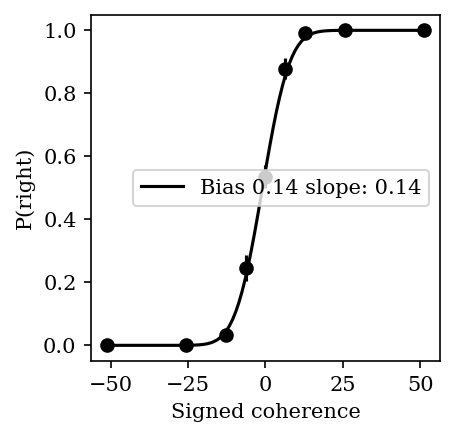

In [ ]:
# plot the probability of choosing right as a function of the signed coherence and then fit a psychometric curve to the data.
mpl.rcParams['font.family'] = ['DejaVu Serif']
from scipy.optimize import curve_fit

f, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=150)
choice = df['choice'].values
# translate choice to 0 and 1
choice_01 = np.copy(choice)
choice_01 -= 1
gt = df['ground_truth'].values
coherence = df['coh'].values
# get signed coherence
signed_coherence = np.copy(coherence)
signed_coherence[gt == 0] = -signed_coherence[gt == 0]

# plot the probability of choosing right as a function of the signed coherence
for sc in np.unique(signed_coherence):
    prob_right = np.mean(choice_01[signed_coherence == sc])
    std_right = np.std(choice_01[signed_coherence == sc])/np.sqrt(np.sum(signed_coherence == sc))
    ax.errorbar(sc, prob_right, yerr=std_right, color='k')
    ax.plot(sc, prob_right, 'o', color='k')

ax.set_xlabel('Signed coherence')
ax.set_ylabel('P(right)')

# fit psychometric curve
pars, _ = curve_fit(probit, signed_coherence, choice_01, p0=[0, 1])
x = np.linspace(-50, 50, 100)
ax.plot(x, probit(x, *pars), color='k', label='Bias ' + str(np.round(pars[0], 2)) + ' slope: ' + str(np.round(pars[1], 2)))
plt.legend()
plt.show()



**Q4 - what do you conclude from this plot? Does the behavioral of the RNN resemble that of a typical subject**

*Copy your response in the Google form*

To get more insight into the RNN behavior, we next analyze how the RNN **integrates sensory information** over the 5 successive time steps that constitute each stimulus (i.e. 500 ms). The relative sensory evidence in each of the 5 frames is stored in the variable `stimulus` of the dataframe. Remember than in each of this time step the stimulus are corrupted with a certain value of noise. We use **logistic regression** to assess the impact of each of these 5 times steps onto the RNN decision.

Optimization terminated successfully.
         Current function value: 0.013528
         Iterations 17


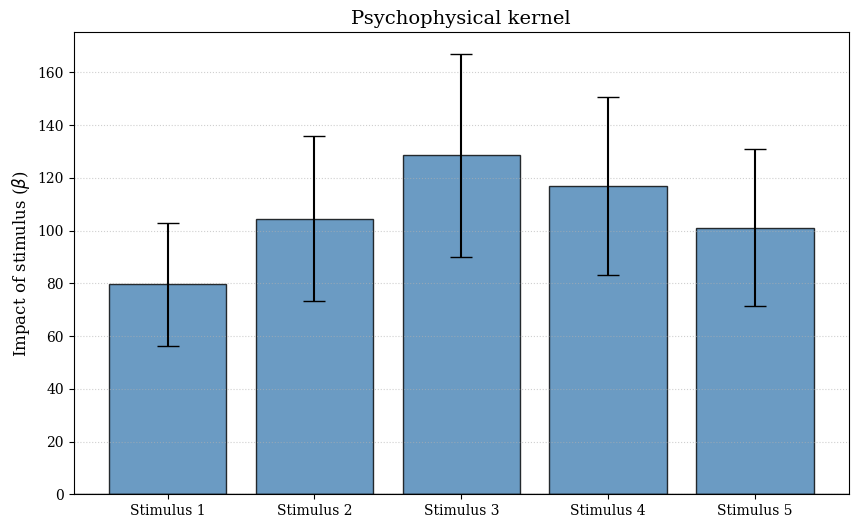

In [ ]:
import statsmodels.api as sm

# Unpack the 5-value arrays into a 2D matrix
stim = np.stack(df['stimulus'].values)
stim = sm.add_constant(stim) # add intercept

# Fit logistic regression model
log_reg = sm.Logit(choice_01, stim)
results = log_reg.fit()

weights = results.params[1:]
errors = results.bse[1:]
labels = [f'Stimulus {i+1}' for i in range(len(weights))]

plt.figure(figsize=(10, 6))
plt.bar(labels, weights, yerr=errors, capsize=8, color='steelblue', alpha=0.8, edgecolor='black')
plt.axhline(0, color='black', linewidth=1) # Baseline at 0
plt.ylabel(r'Impact of stimulus ($\beta$)', fontsize=12)
plt.title('Psychophysical kernel', fontsize=14)
plt.grid(axis='y', linestyle=':', alpha=0.6)

**Q5 - what do you conclude from this plot?**

*Copy your response in the Google form*

# 5. Analysis of neural activity

We will now inspect the network actity and observations. `activity` is of shape (100, 9, 64) (`[nSequence x nTimeStep x nNeuron]`), and observations of shape (100, 9, 3) (`[nSequence x nTimeStep x nobs]`).

Let's plot an example trial: the top panel represents the input variables (fixation and stimulus), the lower panel represents the activity for each of the 64 neurons across time steps, colour coded.

fraction of silent neurons: 0.703125


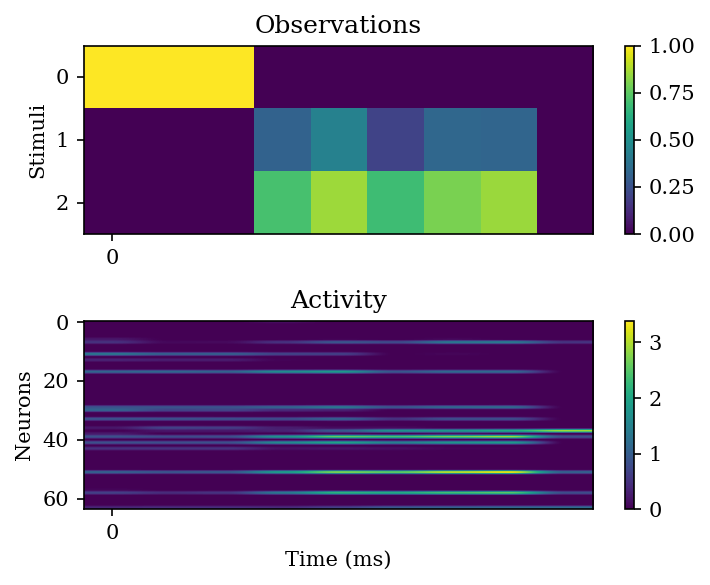

In [ ]:
plot_activity(activity=activity, obs=obs, config=training_kwargs, trial=0)

silent_idx = np.where(activity.sum(axis=(0, 1))==0)[0]
print('fraction of silent neurons:', len(silent_idx)/activity.shape[-1])

**Q6 - what property of the network explains that some neurons stay completely silent?**

*Copy your response in the Google form*

  Let's **exclude silent neurons** from the plot. Also, as in biological networks, the active units of the RNN have different levels of activity. We will thus **normalize the activity** across all trials (so that all neurons have the same minimum and maximum activity) and plot again.

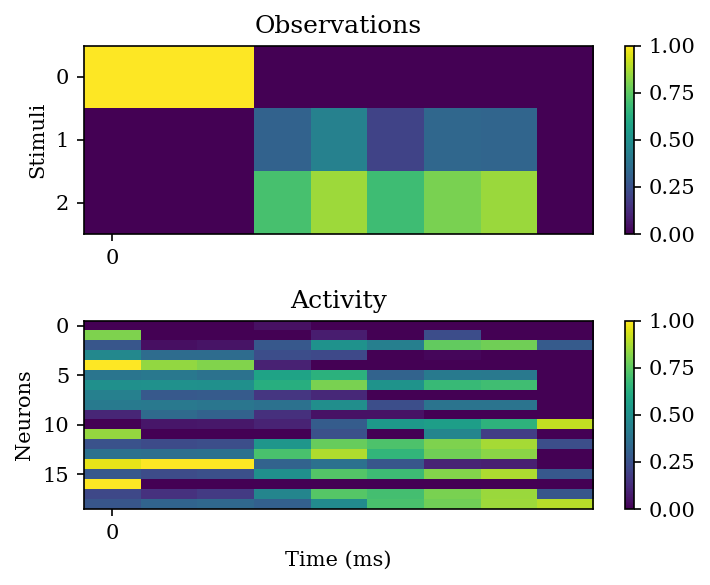

In [ ]:
# exclude silent neurons.
clean_activity = activity[:,:,np.delete(np.arange(activity.shape[-1]), silent_idx)]


# min_max scaling
minmax_activity = np.array([neuron-neuron.min() for neuron in clean_activity.transpose(2,0,1)]).transpose(1,2,0)
minmax_activity = np.array([neuron/neuron.max() for neuron in minmax_activity.transpose(2,0,1)]).transpose(1,2,0)

plot_activity(activity=minmax_activity, obs=obs, config=training_kwargs, trial=0)

We can see that neurons have **mixed activity** profiles, corresponding to the different task periods.

#### Neural activity for different choices
To understand better how the RNN works, we plot the mean activity of each neuron across trials, separately for stimuli leading to the RNN performing a right choice and left choice.

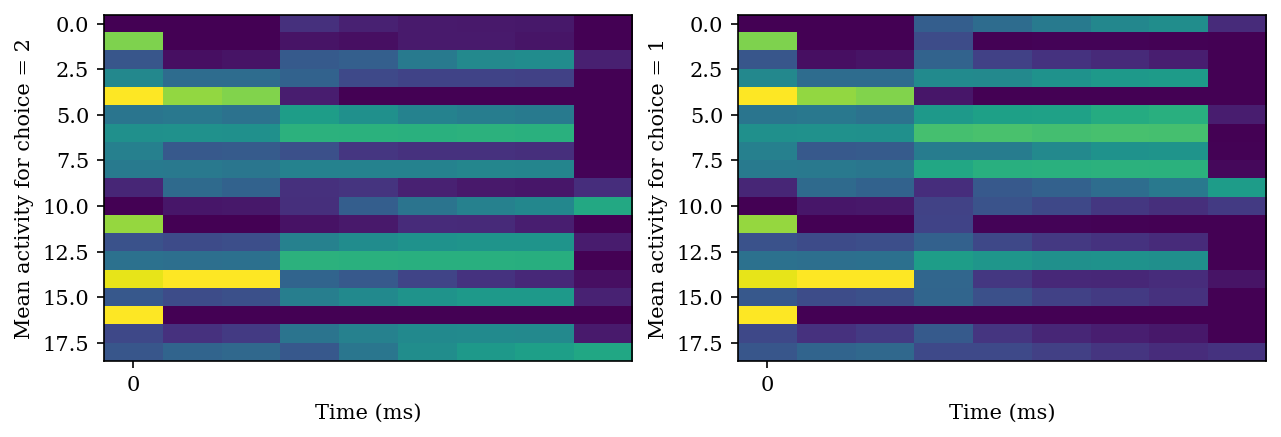

In [ ]:
analysis_activity_by_condition(minmax_activity, df, training_kwargs, conditions=['choice']) # other conditions: correct, ground_truth

As you can see, there are neurons that are more active for one choice than for the other, and likely mediate the transformation from the stimulus to the appropriate response.

**Q7 - What do you think is the function of the neurons that activate similarly for both types of responses?**

*Copy your response in the Google form*

### 4.3. Stimulus and choice decoding from hidden unit activity

We will now look at the information content in the hidden layers: How long does it take (after stimulus presentation) until the RNN represents stimuli reliably? We are going to use **linear discriminant analysis** (`sklda.LinearDiscriminantAnalysis`), which is a simple linear classifier, to perform a **decoding analysis** (we could also have used logistic regression): we will try to decode the identity of the stimulus (left vs. right) from the population activity. Classification accuracy is computed on a test multiple times (similar to cross-validation).

Plot the classification accuracy (together with the 95% CI) over the course of time.

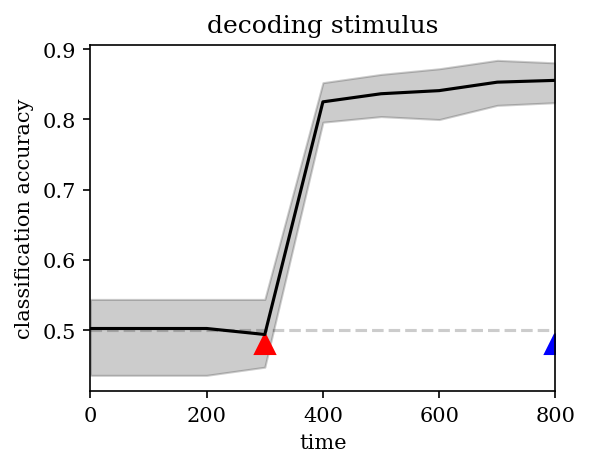

In [ ]:
mean_acc = decoding_from_hidden_units(minmax_activity, df.ground_truth.values)
plot_decoding_results(mean_acc, obs, dt, variable='stimulus')

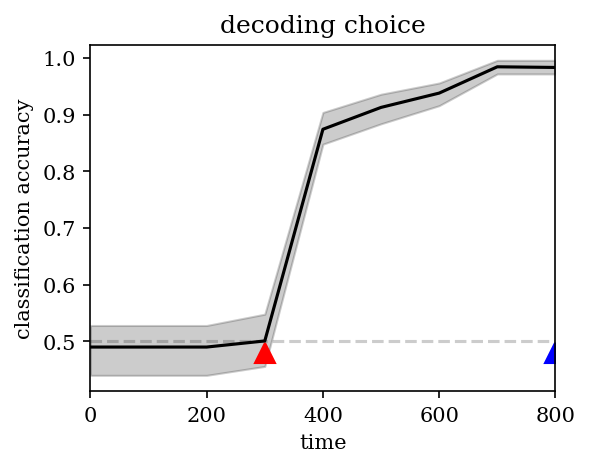

In [ ]:
mean_acc = decoding_from_hidden_units(minmax_activity, df.choice.values)
plot_decoding_results(mean_acc, obs, dt, variable='choice')

**Q8 - Interpret these decoding analyses.**

*We can see that before stimulus presentation, classification accuracy is at chance - of course, the network has not received any information about the stimulus yet. In contrast, information about the stimulus rises quickly after, and then plateaus at high but not perfect value. The decoding of network choice has a similar dynamics, although it keeps increasing until nearly 1. This is because the choice is actually taken from the activity of the network at the final step, and is not completely coupled with the stimulus information*

Will these network dynamics look different for stimuli of different coherence levels? Repeat the same analysis for each level of coherence (`info.coh.values`) and plot the mean accuracy with the pre-specified color gradient. To keep the plot clean, skip confidence intervals.

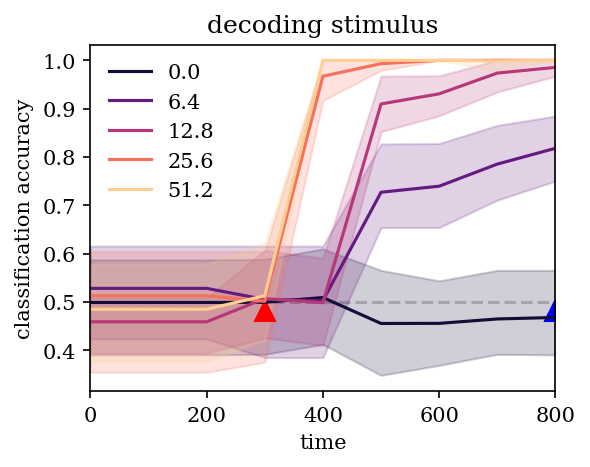

In [ ]:
n_splits=100
mean_acc_coh = np.zeros([n_splits, minmax_activity.shape[1], len(np.unique(df.coh.values))])

for ci,c in enumerate(np.unique(df.coh.values)):
     # get the indices of the trials with the current coherence
    cidx = np.where(df.coh.values==c)

    mean_acc_coh[:,:,ci] = decoding_from_hidden_units(minmax_activity[cidx], df.ground_truth.values[cidx], n_splits=100)

# plot
plot_decoding_results(mean_acc_coh, obs, dt, variable='stimulus', lbl=np.unique(df.coh.values))

**Q9 - How does the decoding of the stimulus changes with coherence? Why?**

*Copy your response in the Google form*

### 4.4 Trajectories in latent space

It's hard to understand what happens in a large population of neurons (this is just 64 but think about the brain!). This is why **dimensionality reduction** techniques that allow to visualize the latent activity of the neural population have become very popular. Here we use  **Principal Component Analysis** (PCA) to reduce the high-dimensional neural population activity (N=64 neurons) into a more interpretable **2D subspace**. We identify the primary axes of variance that define the neural state space across all trials. The resulting visualization maps the neural trajectories of individual sequences, revealing how the population state evolves in each trial. Color-coding these paths by signed coherence illustrates how the magnitude and direction of stimulus evidence  systematically biases the neural dynamics within this low-dimensional manifold. Each trajectory (for a given trial) starts at the triangle and ends at a star.

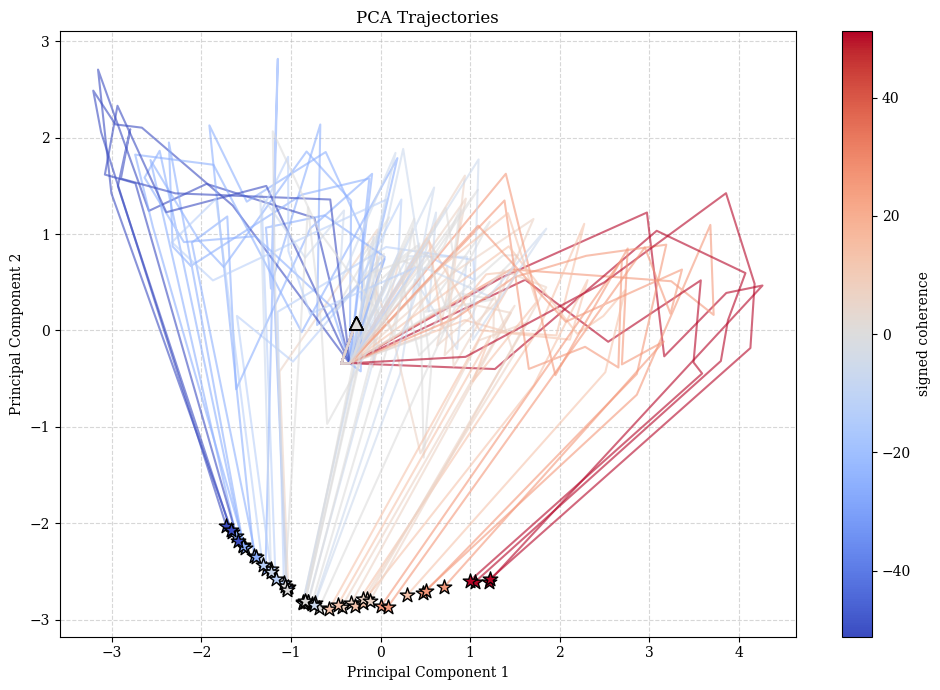

In [ ]:
from sklearn.decomposition import PCA

# Reshape activity for PCA ---
# Flattening sequences and timesteps: (1000 * 24, 64) = (24000, 64)
# This treats every time point of every sequence as an observation of the neural state.
X_flat = activity.reshape(-1, num_neurons)

# --- 3. Perform PCA ---
pca = PCA(n_components=2)
# Fit PCA on the flattened data and project to the first 2 PCs
X_pca = pca.fit_transform(X_flat) # Result is (24000, 2)

# --- 4. Project back to (nSequence, nTimeStep, 2) ---
# Reshape the 2D PCA results back into the 3D structure for plotting trajectories
X_pca_3d = X_pca.reshape(num_seq, num_steps_per_trial, 2)

# Plot the trajectories ---
n_plot_seq = 50 # plot 50 trials (first ones)
plot_latent_trajectories(X_pca_3d, signed_coherence, lbl='signed coherence', n_plot_seq=n_plot_seq)

Here we plot the same trajectories, now colour coded by the **final choice**.

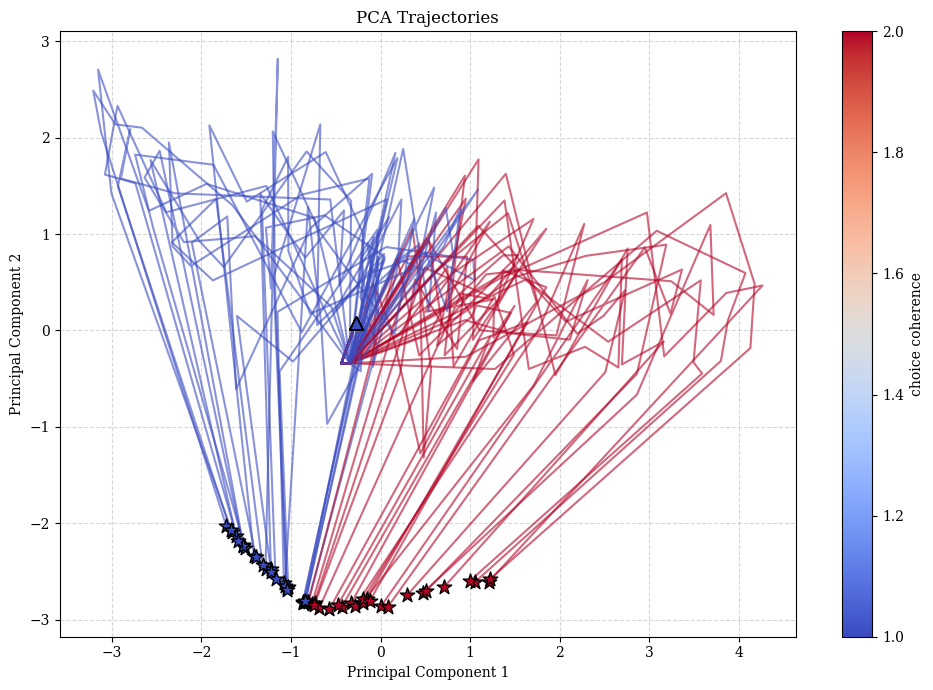

In [ ]:
n_plot_seq = 50 # plot 50 trials (first ones)
plot_latent_trajectories(X_pca_3d, df.choice, lbl='choice coherence', n_plot_seq=n_plot_seq)

**Q10 - How do you interpret the trajectories of the neural population within each trial?**

*Copy your response in the Google form*